<a href="https://colab.research.google.com/github/sstanishk/tanishk-codeboosters-2026/blob/main/Day2/miniprojectday2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libaries imported successfully!")
print(f"SQLite version: {sqlite3.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")


All libaries imported successfully!
SQLite version: 2.6.0
Pandas version: 2.2.2
Matplotlib version: 3.10.0


Creating table 'students' in students.db from 'student_performance.csv'...
Table 'students' created and data loaded.
Query 'Chart1: Average Math Scores by Department' executed successfully.


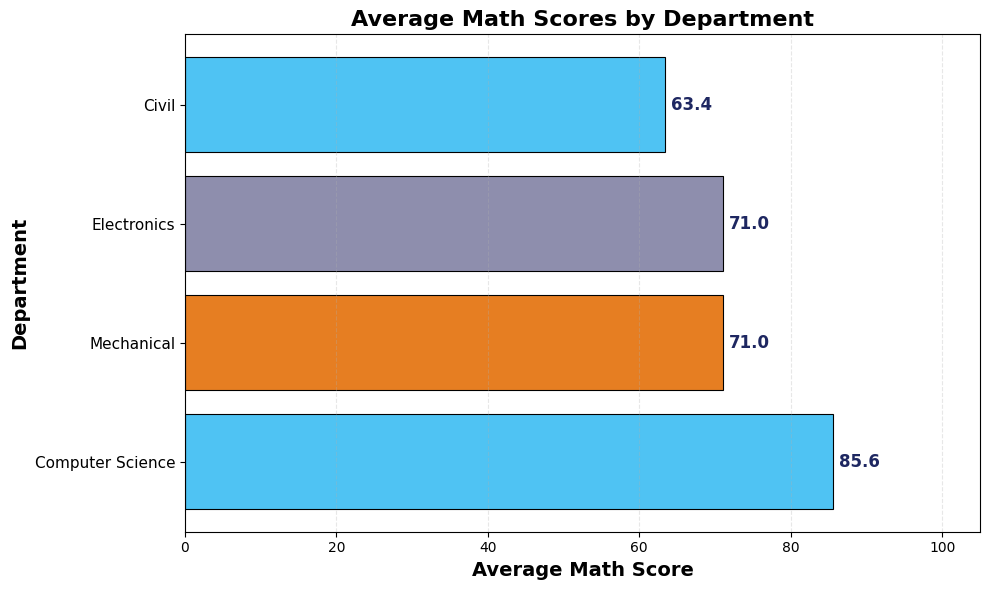

In [5]:
import sqlite3
import pandas as pd

# Define the run_query function
def run_query(sql_query, description="Query"):
    """
    Executes an SQL query on the 'students.db' database and returns the result as a DataFrame.
    If 'students.db' does not exist, it creates it and populates the 'students' table
    from 'student_performance.csv'.
    """
    db_file = 'students.db'
    conn = sqlite3.connect(db_file)

    # Check if the 'students' table exists. If not, create it and load data from CSV.
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='students';")
    if cursor.fetchone() is None:
        print(f"Creating table 'students' in {db_file} from 'student_performance.csv'...")
        try:
            # Load data from student_performance.csv
            df_students = pd.read_csv('student_performance.csv')
            # Assuming column names are appropriate for the SQL query: 'department', 'math_score', 'gender', 'attendance_percentage'
            df_students.to_sql('students', conn, if_exists='replace', index=False)
            print("Table 'students' created and data loaded.")
        except FileNotFoundError:
            print("Error: 'student_performance.csv' not found. Cannot populate 'students' table.")
            return pd.DataFrame()
        except Exception as e:
            print(f"Error loading data into SQLite: {e}")
            return pd.DataFrame()

    try:
        df_result = pd.read_sql_query(sql_query, conn)
        print(f"Query '{description}' executed successfully.")
        return df_result
    except Exception as e:
        print(f"Error executing query '{description}': {e}")
        return pd.DataFrame()
    finally:
        conn.close()

# Original chart code, now with run_query defined
chart1_sql="""
select department,Round(AVG(math_score),2) as avg_math
from students
group by department
order by avg_math desc
"""
chart1_data=run_query(chart1_sql,"Chart1: Average Math Scores by Department")
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#4FC3F3","#E67E22","#8E8EAD"]
bars=ax.barh(  # Changed to barh for horizontal bars
    chart1_data["department"],
    chart1_data["avg_math"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8)
for bar in bars:
  width=bar.get_width() # Get width for horizontal bars
  ax.text(
      width+0.8, # Position text horizontally
      bar.get_y()+bar.get_height()/2, # Center text vertically
      f'{width:.1f}',
      ha='left',va='center', # Align text for horizontal bars
      fontsize=12,fontweight='bold',
      color='#1E2761'
      )
  ax.set_title('Average Math Scores by Department',fontsize=16,fontweight='bold')
  ax.set_ylabel('Department',fontsize=14,fontweight='bold') # Swapped labels
  ax.set_xlabel('Average Math Score',fontsize=14,fontweight='bold') # Swapped labels
  ax.set_xlim(0,105) # Changed to xlim
  ax.tick_params(axis='y',labelsize=11) # Changed to y axis ticks
  ax.grid(axis='x',linestyle='--',alpha=0.3) # Changed to x axis grid
plt.tight_layout()
plt.show()

Query 'Chart2: Average Attendance by Gender' executed successfully.


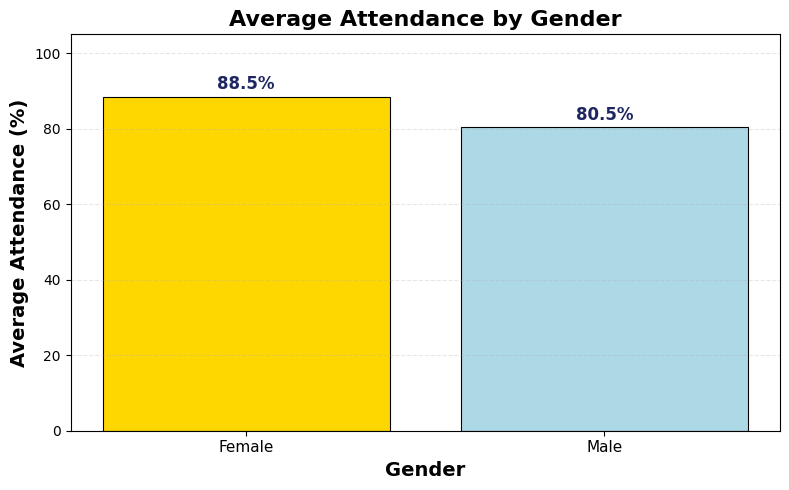

In [6]:
chart2_sql="""
select gender, ROUND(AVG(attendance_percentage), 2) as avg_attendance
from students
group by gender
order by avg_attendance desc
"""
chart2_data=run_query(chart2_sql,"Chart2: Average Attendance by Gender")

fig,ax=plt.subplots(figsize=(8, 5))
bar_colors=["#FFD700", "#ADD8E6"]
bars=ax.bar(
    chart2_data["gender"],
    chart2_data["avg_attendance"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8)

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}%',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='#1E2761'
      )

ax.set_title('Average Attendance by Gender',fontsize=16,fontweight='bold')
ax.set_xlabel('Gender',fontsize=14,fontweight='bold')
ax.set_ylabel('Average Attendance (%)',fontsize=14,fontweight='bold')
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

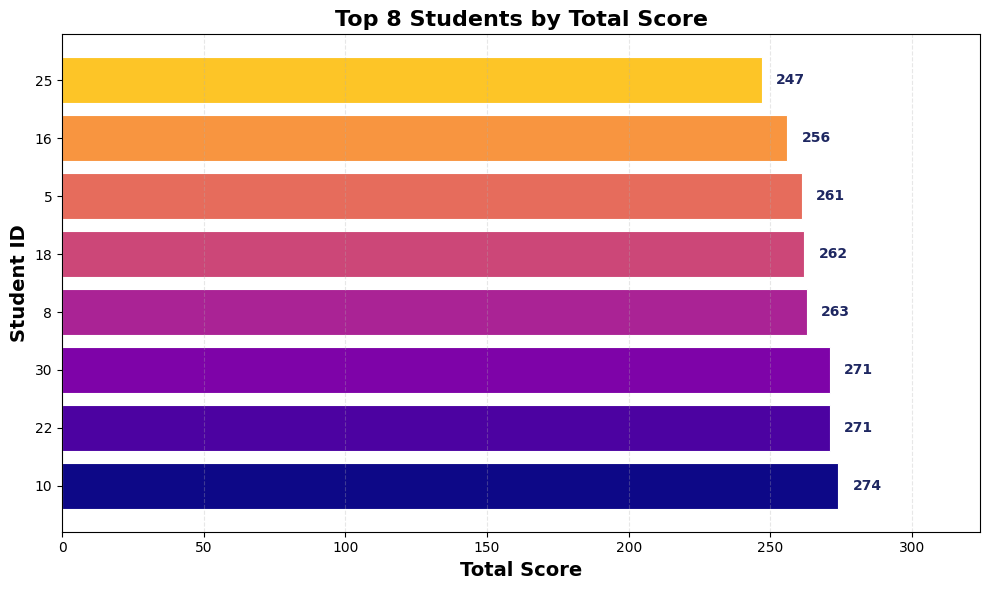

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Re-establish connection to the correct database file
conn = sqlite3.connect('students.db')

# Query to get the top 8 students by math score and their names
# Assuming `name` is not available, using ROWID as student_id
top_8_students_sql = """
SELECT ROWID as student_id,
       (math_score + science_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

try:
    top_8_students_data = pd.read_sql_query(top_8_students_sql, conn)
except pd.io.sql.DatabaseError as e:
    print(f"Error executing SQL query: {e}")
    print("Please ensure 'students' table exists and contains 'math_score', 'science_score', 'english_score' columns.")
    # Handle the case where the table or columns don't exist by creating a dummy DataFrame
    top_8_students_data = pd.DataFrame(columns=['student_id', 'total_score'])


if not top_8_students_data.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Define colors for the bars using a different colormap (e.g., 'plasma')
    bar_colors = plt.cm.plasma(top_8_students_data.index / len(top_8_students_data.index))

    bars = ax.barh(
        top_8_students_data["student_id"].astype(str), # Y-axis for student IDs
        top_8_students_data["total_score"],
        color=bar_colors,
        edgecolor="white",
        linewidth=0.8
    )

    for bar in bars:
        width = bar.get_width() # Get the width of the bar for horizontal plots
        ax.text(
            width + 5, # X-position for the text
            bar.get_y() + bar.get_height() / 2, # Y-position for the text
            f'{width}',
            ha='left', # Align text to the left of the bar
            va='center',
            fontsize=10,
            fontweight='bold',
            color='#1E2761'
        )

    ax.set_title(
        'Top 8 Students by Total Score',
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Total Score', # X-axis label
        fontsize=14,
        fontweight='bold'
    )

    ax.set_ylabel(
        'Student ID', # Y-axis label (reverted to ID as 'name' column is not present)
        fontsize=14,
        fontweight='bold'
    )

    ax.set_xlim(0, top_8_students_data['total_score'].max() + 50) # Adjust x-limit for better spacing
    ax.tick_params(axis='y', labelsize=10) # Adjust ticks for y-axis
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot or an error occurred while fetching data.")

conn.close() # Close connection after use